<a href="https://colab.research.google.com/github/Viker05/-actividad-1-aprendizaje-/blob/main/Act1_Aprendizaje.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Cargar el conjunto de datos
df = pd.read_csv('solicitudes_credito_500.csv')

# Mostrar las primeras 5 filas del archivo
print("--- PRIMERAS FILAS ---")
print(df.head())

# Mostrar la información de las columnas y tipos de datos
print("\n--- INFORMACIÓN GENERAL ---")
print(df.info())

import pandas as pd

# Definir la información detallada de las variables
tabla_variables = [
    {"No.": 1, "Variable": "id_solicitud", "Descripción": "Identificador único de la solicitud", "Tipo de dato": "Texto (object)", "Rol en el modelo": "Identificador (Se excluye)"},
    {"No.": 2, "Variable": "edad", "Descripción": "Edad del cliente en años", "Tipo de dato": "Entero (int64)", "Rol en el modelo": "Variable de entrada (Feature / X)"},
    {"No.": 3, "Variable": "ingreso_mensual", "Descripción": "Ingreso mensual comprobable", "Tipo de dato": "Entero (int64)", "Rol en el modelo": "Variable de entrada (Feature / X)"},
    {"No.": 4, "Variable": "antiguedad_laboral", "Descripción": "Años en el empleo actual", "Tipo de dato": "Decimal (float64)", "Rol en el modelo": "Variable de entrada (Feature / X)"},
    {"No.": 5, "Variable": "historial_crediticio", "Descripción": "Puntaje o score de crédito (Buró)", "Tipo de dato": "Entero (int64)", "Rol en el modelo": "Variable de entrada (Feature / X)"},
    {"No.": 6, "Variable": "creditos_activos", "Descripción": "Número de préstamos/tarjetas vigentes", "Tipo de dato": "Entero (int64)", "Rol en el modelo": "Variable de entrada (Feature / X)"},
    {"No.": 7, "Variable": "utilizacion_credito", "Descripción": "% del límite de crédito en uso", "Tipo de dato": "Decimal (float64)", "Rol en el modelo": "Variable de entrada (Feature / X)"},
    {"No.": 8, "Variable": "pagos_atrasados", "Descripción": "Número de mensualidades atrasadas", "Tipo de dato": "Decimal (float64)", "Rol en el modelo": "Variable de entrada (Feature / X)"},
    {"No.": 9, "Variable": "monto_solicitado", "Descripción": "Cantidad de dinero pedida en préstamo", "Tipo de dato": "Entero (int64)", "Rol en el modelo": "Variable de entrada (Feature / X)"},
    {"No.": 10, "Variable": "plazo_meses", "Descripción": "Plazo del crédito en meses", "Tipo de dato": "Entero (int64)", "Rol en el modelo": "Variable de entrada (Feature / X)"},
    {"No.": 11, "Variable": "riesgo", "Descripción": "Clasificación de riesgo (0 = Bajo, 1 = Alto)", "Tipo de dato": "Entero (int64)", "Rol en el modelo": "Variable objetivo (Target / Y)"}
]

# Crear y mostrar el DataFrame
df_variables = pd.DataFrame(tabla_variables)
display(df_variables)



--- PRIMERAS FILAS ---
  id_solicitud  edad  ingreso_mensual  antiguedad_laboral  \
0      CR-0001    59            31311                 5.2   
1      CR-0002    49            10068                 4.0   
2      CR-0003    35            36237                 9.9   
3      CR-0004    63            11575                12.1   
4      CR-0005    28            10311                14.0   

   historial_crediticio  creditos_activos  utilizacion_credito  \
0                   739                 3                 51.1   
1                   723                 2                 44.1   
2                   755                 4                 45.5   
3                   633                 4                 13.6   
4                   706                 1                 56.3   

   pagos_atrasados  monto_solicitado  plazo_meses  riesgo  
0              0.0             22209           24       0  
1              2.0              3000           48       0  
2              0.0             32

,No.,Variable,Descripción,Tipo de dato,Rol en el modelo
0,1,id_solicitud,Identificador único de la solicitud,Texto (object),Identificador (Se excluye)
1,2,edad,Edad del cliente en años,Entero (int64),Variable de entrada (Feature / X)
2,3,ingreso_mensual,Ingreso mensual comprobable,Entero (int64),Variable de entrada (Feature / X)
3,4,antiguedad_laboral,Años en el empleo actual,Decimal (float64),Variable de entrada (Feature / X)
4,5,historial_crediticio,Puntaje o score de crédito (Buró),Entero (int64),Variable de entrada (Feature / X)
5,6,creditos_activos,Número de préstamos/tarjetas vigentes,Entero (int64),Variable de entrada (Feature / X)
6,7,utilizacion_credito,% del límite de crédito en uso,Decimal (float64),Variable de entrada (Feature / X)
7,8,pagos_atrasados,Número de mensualidades atrasadas,Decimal (float64),Variable de entrada (Feature / X)
8,9,monto_solicitado,Cantidad de dinero pedida en préstamo,Entero (int64),Variable de entrada (Feature / X)
9,10,plazo_meses,Plazo del crédito en meses,Entero (int64),Variable de entrada (Feature / X)


In [ ]:
# Definición del sistema tradicional basado en reglas
def evaluar_riesgo_tradicional(row):
    # Regla 1: Atrasos recurrentes
    if row['pagos_atrasados'] >= 3:
        return 1
    # Regla 2: Saturación de líneas de crédito
    elif row['utilizacion_credito'] > 80.0:
        return 1
    # Regla 3: Bajo Score y Alto Monto
    elif row['historial_crediticio'] < 580 and row['monto_solicitado'] > 50000:
        return 1
    # Regla 4: Inestabilidad laboral e ingresos bajos
    elif row['antiguedad_laboral'] < 1.0 and row['ingreso_mensual'] < 12000:
        return 1
    # Regla 5: Múltiples créditos con al menos un atraso
    elif row['creditos_activos'] >= 5 and row['pagos_atrasados'] >= 1:
        return 1
    # Criterio por defecto
    else:
        return 0

# Aplicar las reglas a cada fila del DataFrame
df['riesgo_tradicional'] = df.apply(evaluar_riesgo_tradicional, axis=1)

# Mostrar las primeras filas comparando la predicción tradicional vs la real
df[['id_solicitud', 'pagos_atrasados', 'utilizacion_credito', 'historial_crediticio', 'riesgo_tradicional', 'riesgo']].head(10)

,id_solicitud,pagos_atrasados,utilizacion_credito,historial_crediticio,riesgo_tradicional,riesgo
0,CR-0001,0.0,51.1,739,0,0
1,CR-0002,2.0,44.1,723,0,0
2,CR-0003,0.0,45.5,755,0,0
3,CR-0004,0.0,13.6,633,0,1
4,CR-0005,1.0,56.3,706,0,0
5,CR-0006,0.0,40.4,639,0,1
6,CR-0007,1.0,47.5,601,0,1
7,CR-0008,0.0,46.5,677,0,0
8,CR-0009,0.0,47.0,611,0,1
9,CR-0010,0.0,50.7,768,0,0


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Cargar el conjunto de datos
df = pd.read_csv('solicitudes_credito_500.csv')

# 1. Tratamiento de valores nulos (imputación con la mediana/moda)
df_sup = df.copy()
df_sup['antiguedad_laboral'] = df_sup['antiguedad_laboral'].fillna(df_sup['antiguedad_laboral'].median())
df_sup['utilizacion_credito'] = df_sup['utilizacion_credito'].fillna(df_sup['utilizacion_credito'].median())
df_sup['pagos_atrasados'] = df_sup['pagos_atrasados'].fillna(df_sup['pagos_atrasados'].mode()[0])

# 2. Definición de X (Variables de entrada) e Y (Variable objetivo)
X = df_sup[['edad', 'ingreso_mensual', 'antiguedad_laboral', 'historial_crediticio',
            'creditos_activos', 'utilizacion_credito', 'pagos_atrasados',
            'monto_solicitado', 'plazo_meses']]

y = df_sup['riesgo']

# 3. División de datos en conjunto de Entrenamiento (80%) y Prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Creación e inicialización del modelo de Aprendizaje Supervisado
modelo_supervisado = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_supervisado.fit(X_train, y_train)

# 5. Evaluación del modelo
y_pred = modelo_supervisado.predict(X_test)
exactitud = accuracy_score(y_test, y_pred)

print(f"=== EVALUACIÓN DEL MODELO SUPERVISADO ===")
print(f"Precisión (Accuracy) en conjunto de prueba: {exactitud * 100:.2f}%\n")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred))

=== EVALUACIÓN DEL MODELO SUPERVISADO ===
Precisión (Accuracy) en conjunto de prueba: 76.00%

Matriz de Confusión:
[[46  9]
 [15 30]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.75      0.84      0.79        55
           1       0.77      0.67      0.71        45

    accuracy                           0.76       100
   macro avg       0.76      0.75      0.75       100
weighted avg       0.76      0.76      0.76       100



In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Cargar el conjunto de datos
df = pd.read_csv('solicitudes_credito_500.csv')

# 1. Tratamiento de valores nulos (imputación con la mediana/moda)
df_sup = df.copy()
df_sup['antiguedad_laboral'] = df_sup['antiguedad_laboral'].fillna(df_sup['antiguedad_laboral'].median())
df_sup['utilizacion_credito'] = df_sup['utilizacion_credito'].fillna(df_sup['utilizacion_credito'].median())
df_sup['pagos_atrasados'] = df_sup['pagos_atrasados'].fillna(df_sup['pagos_atrasados'].mode()[0])

# 2. Definición de X (Variables de entrada) e Y (Variable objetivo)
X = df_sup[['edad', 'ingreso_mensual', 'antiguedad_laboral', 'historial_crediticio',
            'creditos_activos', 'utilizacion_credito', 'pagos_atrasados',
            'monto_solicitado', 'plazo_meses']]

y = df_sup['riesgo']

# Separación 80% entrenamiento y 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Total de registros: {len(X)}")
print(f"Entrenamiento (X_train): {len(X_train)} (80%)")
print(f"Prueba (X_test): {len(X_test)} (20%)")

Total de registros: 500
Entrenamiento (X_train): 400 (80%)
Prueba (X_test): 100 (20%)


In [ ]:
from sklearn.tree import DecisionTreeClassifier

# 1. Crear e inicializar el modelo de Árbol de Decisión
modelo_arbol = DecisionTreeClassifier(max_depth=4, random_state=42)

# 2. Entrenar el modelo con el 80% de los datos (X_train, y_train)
modelo_arbol.fit(X_train, y_train)

print("¡Modelo Árbol de Decisión entrenado exitosamente!")

¡Modelo Árbol de Decisión entrenado exitosamente!


In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix

# 1. Generar predicciones sobre el conjunto de prueba
y_pred = modelo_arbol.predict(X_test)

# 2. Crear Tabla Comparativa
df_comparativa = pd.DataFrame({
    'Riesgo_Real': y_test.values,
    'Prediccion_Modelo': y_pred
})
df_comparativa['Resultado'] = df_comparativa.apply(
    lambda r: 'Correcto' if r['Riesgo_Real'] == r['Prediccion_Modelo'] else 'Error', axis=1
)

print("=== TABLA COMPARATIVA (PRIMEROS 10 REGISTROS) ===")
print(df_comparativa.head(10))

# 3. Métricas de Evaluación
print("\n=== EVALUACIÓN ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Matriz de Confusión:")
print(confusion_matrix(y_test, y_pred))

=== TABLA COMPARATIVA (PRIMEROS 10 REGISTROS) ===
   Riesgo_Real  Prediccion_Modelo Resultado
0            1                  1  Correcto
1            1                  0     Error
2            0                  0  Correcto
3            1                  1  Correcto
4            0                  0  Correcto
5            0                  0  Correcto
6            0                  1     Error
7            1                  0     Error
8            0                  0  Correcto
9            1                  0     Error

=== EVALUACIÓN ===
Accuracy: 75.00%

Matriz de Confusión:
[[47  5]
 [20 28]]


In [ ]:
from sklearn.preprocessing import StandardScaler

# 1. Seleccionar variables de perfil financiero
variables_perfil = [
    'ingreso_mensual', 'historial_crediticio', 'creditos_activos',
    'utilizacion_credito', 'pagos_atrasados', 'monto_solicitado'
]

X_cluster = df_sup[variables_perfil]

# 2. Aplicar StandardScaler para normalizar las escalas
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print("=== VARIABLES ESCALADAS EXITOSAMENTE ===")
print("Forma de la matriz normalizada:", X_scaled.shape)

=== VARIABLES ESCALADAS EXITOSAMENTE ===
Forma de la matriz normalizada: (500, 6)


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Cargar el dataset (asegúrate de que el nombre del archivo coincida con el tuyo)
df = pd.read_csv('solicitudes_credito_500.csv')

# 2. Copia y limpieza de nulos
df_preparado = df.copy()
df_preparado['antiguedad_laboral'].fillna(df_preparado['antiguedad_laboral'].median(), inplace=True)
df_preparado['utilizacion_credito'].fillna(df_preparado['utilizacion_credito'].median(), inplace=True)
df_preparado['pagos_atrasados'].fillna(df_preparado['pagos_atrasados'].mode()[0], inplace=True)

# 3. Variables para clustering
variables_perfil = [
    'ingreso_mensual', 'historial_crediticio', 'creditos_activos',
    'utilizacion_credito', 'pagos_atrasados', 'monto_solicitado'
]

X_cluster = df_preparado[variables_perfil]

# 4. Escalamiento y K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_preparado['cluster'] = kmeans.fit_predict(X_scaled)

# 5. Resultado
print("=== DISTRIBUCIÓN DE CLIENTES POR CLUSTER ===")
print(df_preparado['cluster'].value_counts().sort_index())

=== DISTRIBUCIÓN DE CLIENTES POR CLUSTER ===
cluster
0    198
1     66
2    236
Name: count, dtype: int64


/tmp/ipykernel_605/2601503021.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_preparado['antiguedad_laboral'].fillna(df_preparado['antiguedad_laboral'].median(), inplace=True)
/tmp/ipykernel_605/2601503021.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

In [ ]:
# Calcular las medias de las variables financieras por cluster
perfiles = df_preparado.groupby('cluster')[variables_perfil].mean().round(2)
print("=== CARACTERÍSTICAS PROMEDIO POR CLUSTER ===")
print(perfiles)

=== CARACTERÍSTICAS PROMEDIO POR CLUSTER ===
         ingreso_mensual  historial_crediticio  creditos_activos  \
cluster                                                            
0               17331.98                716.10              1.86   
1               40273.91                681.92              2.41   
2               18018.05                661.19              2.44   

         utilizacion_credito  pagos_atrasados  monto_solicitado  
cluster                                                          
0                      28.09             1.29          15297.31  
1                      38.16             1.26          45184.33  
2                      57.56             0.75          15730.29  


In [ ]:
import numpy as np
import pandas as pd

# 1. Definir Estados, Acciones y la Matriz de Recompensas
estados = ['Bajo riesgo', 'Alto riesgo']
acciones = ['Rechazar', 'Revisar', 'Aprobar']

# Matriz [Filas: Estados, Columnas: Acciones]
q_table = np.array([
    [-3,  1, 10],   # Bajo riesgo
    [ 8,  1, -10]   # Alto riesgo
])

# 2. Simular 10 solicitudes de crédito aleatorias
np.random.seed(42)
solicitudes_simuladas = np.random.choice([0, 1], size=10) # 0: Bajo riesgo, 1: Alto riesgo

resultados = []
recompensa_total = 0

for i, est_idx in enumerate(solicitudes_simuladas, 1):
    estado_actual = estados[est_idx]

    # El agente elige la acción con la mayor recompensa en la Q-Table (Política Óptima)
    accion_optima_idx = np.argmax(q_table[est_idx])
    accion_tomada = acciones[accion_optima_idx]
    recompensa = q_table[est_idx, accion_optima_idx]

    recompensa_total += recompensa
    resultados.append({
        'Solicitud': f'#{i}',
        'Estado del Cliente': estado_actual,
        'Acción del Agente': accion_tomada,
        'Recompensa Obt.': recompensa,
        'Acumulado': recompensa_total
    })

# 3. Mostrar resultados de la simulación
df_simulacion = pd.DataFrame(resultados)
print("=== RESULTADOS DE LA SIMULACIÓN DE DECISIONES DE CRÉDITO ===")
print(df_simulacion.to_string(index=False))

=== RESULTADOS DE LA SIMULACIÓN DE DECISIONES DE CRÉDITO ===
Solicitud Estado del Cliente Acción del Agente  Recompensa Obt.  Acumulado
       #1        Bajo riesgo           Aprobar               10         10
       #2        Alto riesgo          Rechazar                8         18
       #3        Bajo riesgo           Aprobar               10         28
       #4        Bajo riesgo           Aprobar               10         38
       #5        Bajo riesgo           Aprobar               10         48
       #6        Alto riesgo          Rechazar                8         56
       #7        Bajo riesgo           Aprobar               10         66
       #8        Bajo riesgo           Aprobar               10         76
       #9        Bajo riesgo           Aprobar               10         86
      #10        Alto riesgo          Rechazar                8         94


In [ ]:
import numpy as np
import pandas as pd

# 1. Definir estados y acciones
estados = ['Bajo riesgo', 'Alto riesgo']
acciones = ['Rechazar (0)', 'Revisar (1)', 'Aprobar (2)']

# 2. Inicializar la Tabla Q en ceros (agente sin conocimiento inicial)
q_tabla_inicial = np.zeros((len(estados), len(acciones)))

# 3. Presentar en un DataFrame
df_q_inicial = pd.DataFrame(q_tabla_inicial, index=estados, columns=acciones)

print("=== TABLA Q INICIALIZADA (SIN CONOCIMIENTO PREVIO) ===")
print(df_q_inicial)

=== TABLA Q INICIALIZADA (SIN CONOCIMIENTO PREVIO) ===
             Rechazar (0)  Revisar (1)  Aprobar (2)
Bajo riesgo           0.0          0.0          0.0
Alto riesgo           0.0          0.0          0.0


In [ ]:
import numpy as np
import pandas as pd

# 1. Parámetros del algoritmo Q-Learning
alpha = 0.1     # Tasa de aprendizaje
gamma = 0.9     # Factor de descuento
episodes = 1000 # Número de iteraciones simuladas

# 2. Inicializar Q-Table en ceros
q_table = np.zeros((2, 3)) # 2 Estados, 3 Acciones

# Matriz de Recompensas R[estado][accion]
recompensas = np.array([
    [-3,  1, 10],   # Bajo riesgo: [Rechazar, Revisar, Aprobar]
    [ 8,  1, -10]   # Alto riesgo: [Rechazar, Revisar, Aprobar]
])

# 3. Proceso de entrenamiento mediante iteración
np.random.seed(42)
for _ in range(episodes):
    estado = np.random.choice([0, 1]) # Selección aleatoria de cliente

    # Política epsilon-greedy para exploración y explotación
    if np.random.rand() < 0.2:
        accion = np.random.choice([0, 1, 2]) # Explorar
    else:
        accion = np.argmax(q_table[estado])  # Explotar el mejor valor Q

    recompensa = recompensas[estado][accion]

    # Actualización de Bellman / Q-Learning
    q_table[estado, accion] = q_table[estado, accion] + alpha * (recompensa + gamma * np.max(q_table[estado]) - q_table[estado, accion])

# 4. Presentar la Tabla Q Entrenada
estados_labels = ['Bajo riesgo', 'Alto riesgo']
acciones_labels = ['Rechazar (0)', 'Revisar (1)', 'Aprobar (2)']
df_q_final = pd.DataFrame(np.round(q_table, 2), index=estados_labels, columns=acciones_labels)

print("=== TABLA Q FINAL (DESPUÉS DE 1,000 ITERACIONES) ===")
print(df_q_final)

=== TABLA Q FINAL (DESPUÉS DE 1,000 ITERACIONES) ===
             Rechazar (0)  Revisar (1)  Aprobar (2)
Bajo riesgo         78.65        83.70        98.76
Alto riesgo         78.96        59.18        52.03


/tmp/ipykernel_2285/2003174261.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_preparado['antiguedad_laboral'].fillna(df_preparado['antiguedad_laboral'].median(), inplace=True)
/tmp/ipykernel_2285/2003174261.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

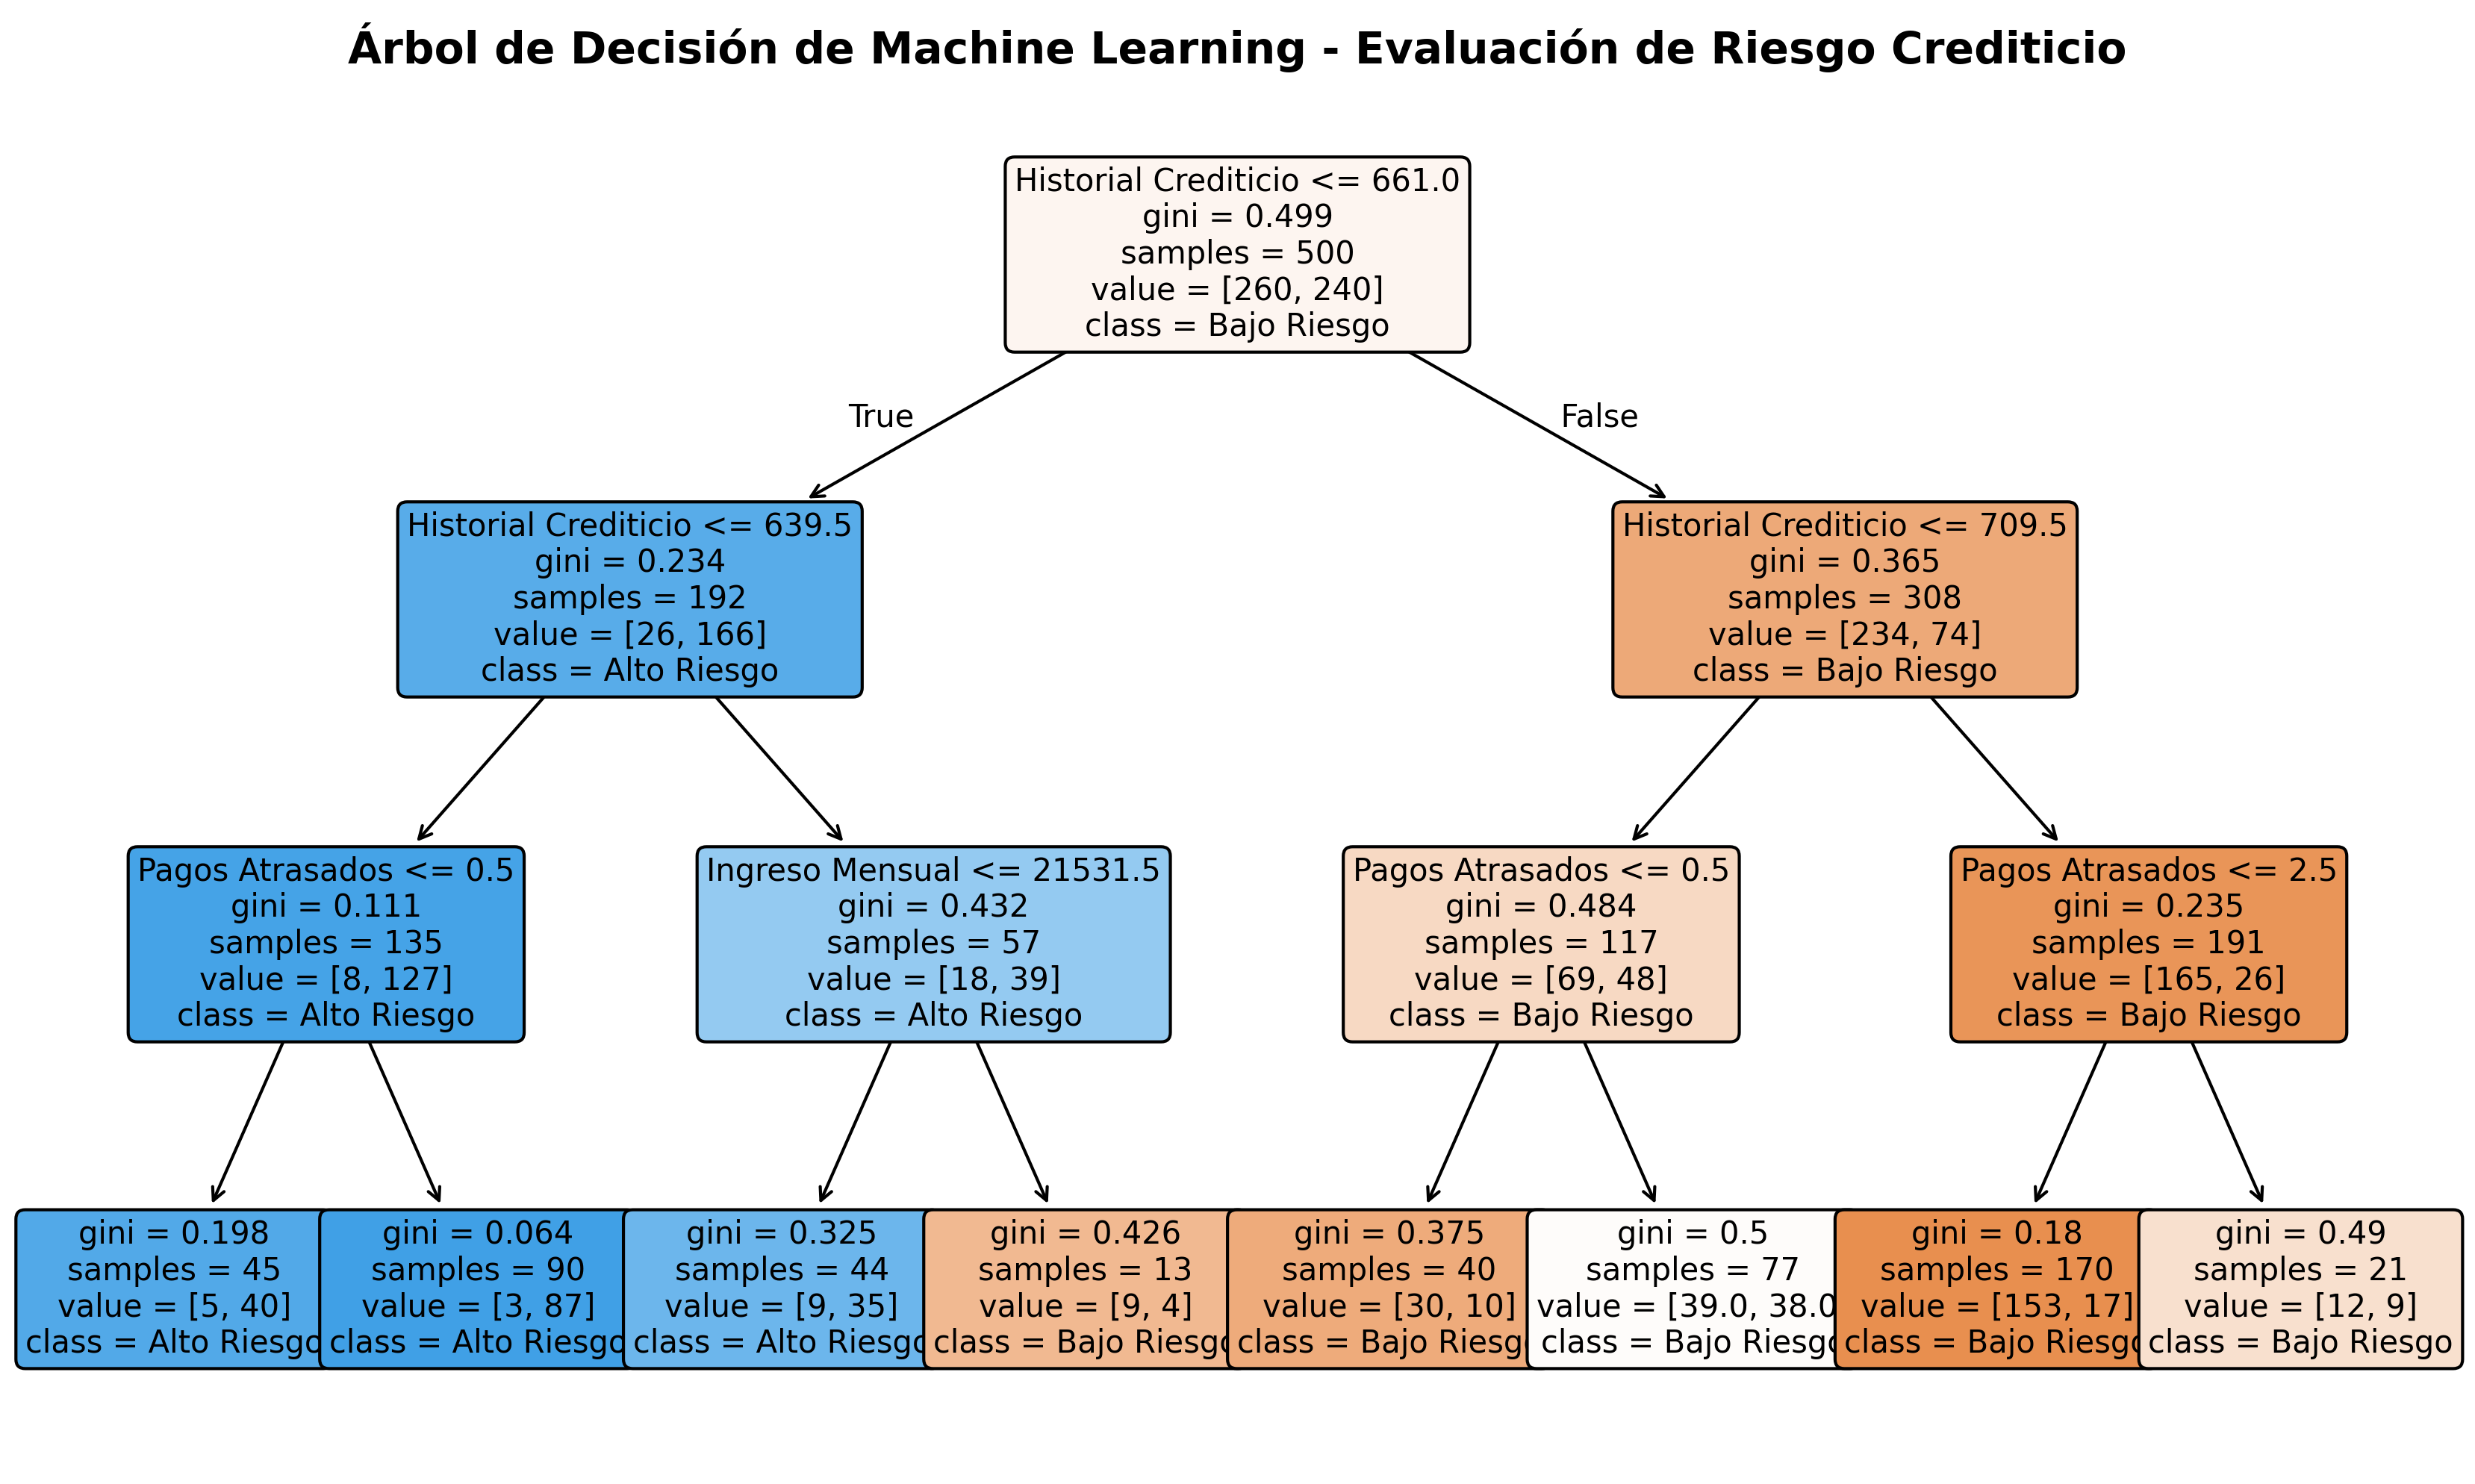

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
import pandas as pd

# Re-loading and preparing df_preparado for this cell's scope
df = pd.read_csv('solicitudes_credito_500.csv')
df_preparado = df.copy()
df_preparado['antiguedad_laboral'].fillna(df_preparado['antiguedad_laboral'].median(), inplace=True)
df_preparado['utilizacion_credito'].fillna(df_preparado['utilizacion_credito'].median(), inplace=True)
df_preparado['pagos_atrasados'].fillna(df_preparado['pagos_atrasados'].mode()[0], inplace=True)

# 1. Entrenar un árbol de decisión simplificado con tus variables del banco
X_ejemplo = df_preparado[['historial_crediticio', 'ingreso_mensual', 'pagos_atrasados']]
y_ejemplo = df_preparado['riesgo'] # O tu variable objetivo (0: Bajo Riesgo, 1: Alto Riesgo)

modelo_arbol = DecisionTreeClassifier(max_depth=3, random_state=42)
modelo_arbol.fit(X_ejemplo, y_ejemplo)

# 2. Graficar el árbol de decisión de Machine Learning
plt.figure(figsize=(14, 8), dpi=300)
plot_tree(
    modelo_arbol,
    feature_names=['Historial Crediticio', 'Ingreso Mensual', 'Pagos Atrasados'],
    class_names=['Bajo Riesgo', 'Alto Riesgo'],
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Árbol de Decisión de Machine Learning - Evaluación de Riesgo Crediticio", fontsize=14, fontweight='bold')
plt.show()